# Data Cleaning and Preprocessing

## 1. Goal:
- Prepare a clean and consistent dataset ready for modeling
- Remove redundant and zero-variance columns identified during exploration
- Handle duplicates, missing values, outliers, and inconsistent formats
- Save the cleaned dataset to `data/processed/`

## 2. Imports

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 3. Load Dataset

Load the raw dataset and verify shape before any transformations.

In [42]:
df = pd.read_csv("../data/raw/postings.csv")

In [43]:
print(f"Shape: {df.shape}")
df.head()

Shape: (123849, 31)


,job_id,company_name,title,description,max_salary,pay_period,location,company_id,views,med_salary,...,skills_desc,listed_time,posting_domain,sponsored,work_type,currency,compensation_type,normalized_salary,zip_code,fips
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,Job descriptionA leading real estate firm in N...,20.0,HOURLY,"Princeton, NJ",2774458.0,20.0,NaN,...,Requirements: \n\nWe are seeking a College or ...,1.713398e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,38480.0,8540.0,34021.0
1,1829192,NaN,Mental Health Therapist/Counselor,"At Aspen Therapy and Wellness , we are committ...",50.0,HOURLY,"Fort Collins, CO",NaN,1.0,NaN,...,NaN,1.712858e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,83200.0,80521.0,8069.0
2,10998357,The National Exemplar,Assitant Restaurant Manager,The National Exemplar is accepting application...,65000.0,YEARLY,"Cincinnati, OH",64896719.0,8.0,NaN,...,We are currently accepting resumes for FOH - A...,1.713278e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,55000.0,45202.0,39061.0
3,23221523,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...,Senior Associate Attorney - Elder Law / Trusts...,175000.0,YEARLY,"New Hyde Park, NY",766262.0,16.0,NaN,...,This position requires a baseline understandin...,1.712896e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,157500.0,11040.0,36059.0
4,35982263,NaN,Service Technician,Looking for HVAC service tech with experience ...,80000.0,YEARLY,"Burlington, IA",NaN,3.0,NaN,...,NaN,1.713452e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,70000.0,52601.0,19057.0


## 4. Drop zero-variance and redundant columns

### 4.1 Zero-variance and unnecessary columns

Based on findings from the initial exploration:
- **Zero-variance columns**: `sponsored` (always False) and `compensation_type` (single value) provide no information and can be dropped immediately
- **Redundant columns**: `job_posting_url` and `application_url` dont carry any analytical value and will be dropped
- **Deferred**: `min_salary` / `max_salary` are nearly perfectly correlated (r = 0.99), but the decision on which to drop will come after outlier treatment

> **Note:** Although `remote_allowed` has a standard deviation of 0, missing values can be assumed to represent False, so this column will not be dropped.

In [44]:
# Verify zero-variance assumptions
for col in ['sponsored', 'compensation_type']:
    print(f"{col}: {df[col].nunique()} unique values -> {df[col].value_counts().to_dict()}")

sponsored: 1 unique values -> {0: 123849}
compensation_type: 1 unique values -> {'BASE_SALARY': 36073}


In [ ]:
cols_to_drop = [
    # Zero-variance
    'sponsored',
    'compensation_type',

    # Not useful for modeling
    'job_posting_url',
    # 'job_id', saved for feature merging but not useful as a standalone feature
    'application_url'

]

df.drop(columns=cols_to_drop, inplace=True)
print(f"Shape after dropping columns: {df.shape}")

Shape after dropping columns: (123849, 26)


### 4.2 Redundant column: `work_type`


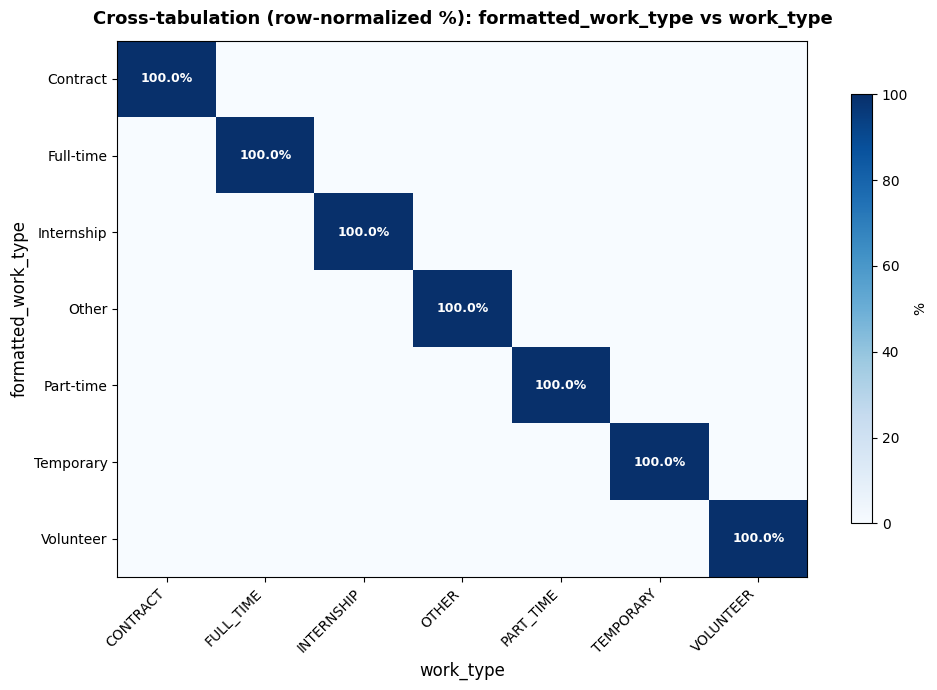

In [46]:
ct_norm = pd.crosstab(df['formatted_work_type'], df['work_type'], normalize='index') * 100

fig, ax = plt.subplots(figsize=(10, 7))
im = ax.imshow(ct_norm.values, cmap='Blues', aspect='auto')

ax.set_xticks(range(len(ct_norm.columns)))
ax.set_yticks(range(len(ct_norm.index)))
ax.set_xticklabels(ct_norm.columns, rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(ct_norm.index, fontsize=10)
ax.set_xlabel('work_type', fontsize=12)
ax.set_ylabel('formatted_work_type', fontsize=12)

for i in range(len(ct_norm.index)):
    for j in range(len(ct_norm.columns)):
        val = ct_norm.values[i, j]
        if val > 0.5:
            color = 'white' if val > 50 else 'black'
            ax.text(j, i, f'{val:.1f}%', ha='center', va='center', fontsize=9,
                    fontweight='bold', color=color)

fig.colorbar(im, ax=ax, label='%', shrink=0.8)
ax.set_title('Cross-tabulation (row-normalized %): formatted_work_type vs work_type',
             fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

In [47]:
df.drop(columns='work_type', inplace=True)
print(f"Shape after dropping columns: {df.shape}")

Shape after dropping columns: (123849, 25)


A cross-tabulation between `formatted_work_type` and `work_type` reveals a perfect 1-to-1 mapping (100% on the diagonal, 0% everywhere else). The two columns encode the same information in different formats: `formatted_work_type` uses readable labels (e.g., "Full-time") while `work_type` uses uppercase/underscore notation (e.g., "FULL_TIME"). Since they are fully redundant, `work_type` is dropped, keeping `formatted_work_type` as the cleaner version.

### 4.3 Nearly empty columns: `closed_time` and `skills_desc`

In [48]:
# Check missingness for closed_time and skills_desc
for col in ['closed_time', 'skills_desc']:
    total = len(df)
    missing = df[col].isna().sum()
    pct = missing / total * 100
    print(f"Missing {col}: {missing} / {total} ({pct:.2f}%)")

Missing closed_time: 122776 / 123849 (99.13%)
Missing skills_desc: 121410 / 123849 (98.03%)


In [49]:
# closed_time: check if it can be derived from existing time features
time_cols = ['original_listed_time', 'listed_time', 'expiry']
print("Missing values in time-related columns:")
for col in time_cols:
    print(f"  {col}: {df[col].isna().sum()}")

Missing values in time-related columns:
  original_listed_time: 0
  listed_time: 0
  expiry: 0


In [50]:
# skills_desc: check if description exists for every row that has skills_desc
has_skills = df['skills_desc'].notna()
has_desc = df.loc[has_skills, 'description'].notna()

print(f"Rows with skills_desc: {has_skills.sum()}")
print(f"Of those, rows also having description: {has_desc.sum()}")
print(f"Rows with skills_desc but missing description: {has_skills.sum() - has_desc.sum()}")

Rows with skills_desc: 2439
Of those, rows also having description: 2439
Rows with skills_desc but missing description: 0


In [51]:
# Drop both columns
df.drop(columns=['closed_time', 'skills_desc'], inplace=True)
print(f"Shape after dropping columns: {df.shape}")

Shape after dropping columns: (123849, 23)


**`closed_time`** is 99.13% missing (only 1,073 non-null values). Since `original_listed_time`, `listed_time`, and `expiry` all have zero missing values, any time-based features (e.g., posting duration) can be derived from those columns instead. Keeping `closed_time` adds no value given its sparsity.

**`skills_desc`** is 98.03% missing (only 2,439 non-null values). Every row that has a `skills_desc` also has a `description`, meaning the skills information does not appear to carry any additional unique content. The column is too sparse for imputation or reliable analysis. If skills-based features are needed later (e.g., during Feature Engineering), they can be extracted from `description` using NLP techniques.

## 5. Duplicate removal

The initial exploration confirmed that there are no fully identical rows and no duplicate `job_id` values. However, after dropping several columns in section 4, rows that previously differed only in those removed columns may now be identical. We check for and remove such complete duplicates (excluding `job_id`, which is unique by design and would mask them).

In [52]:
dup_cols = [c for c in df.columns if c != 'job_id']
dup_mask_all = df.duplicated(subset=dup_cols, keep=False)
dup_mask_extra = df.duplicated(subset=dup_cols, keep='first')

print(f"Rows involved in duplicate groups: {dup_mask_all.sum():,}")
print(f"Duplicate rows to remove: {dup_mask_extra.sum():,}")

Rows involved in duplicate groups: 565
Duplicate rows to remove: 304


In [53]:
shape_before = df.shape[0]

# Keep first occurrence, drop the rest
df.drop_duplicates(subset=dup_cols, keep='first', inplace=True)
df.reset_index(drop=True, inplace=True)

rows_removed = shape_before - df.shape[0]
print(f"Rows before: {shape_before:,}")
print(f"Rows removed: {rows_removed:,}")
print(f"Rows after: {df.shape[0]:,}")

Rows before: 123,849
Rows removed: 304
Rows after: 123,545


**#todo**: maybe remove more duplicates


## 6. Text cleaning

### Lowercasing and stripping whitespace
Several text columns contain inconsistent casing and leading or trailing whitespace, which can cause identical values to appear distinct during analysis. We compare the number of unique values before and after standardizing `title`, `company_name`, `location`, and `description` by converting all text to lowercase and stripping extra whitespace from both ends.

In [54]:
cols_to_clean = ['company_name', 'title', 'description', 'location']

print("Unique values BEFORE cleaning:")
print(df[cols_to_clean].nunique())

df['title'] = df['title'].str.lower().str.strip()
df['company_name'] = df['company_name'].str.lower().str.strip()
df['location'] = df['location'].str.lower().str.strip()
df['description'] = df['description'].str.lower().str.strip()

print("\nUnique values AFTER cleaning:")
print(df[cols_to_clean].nunique())

Unique values BEFORE cleaning:
company_name     24428
title            72521
description     107827
location          8526
dtype: int64

Unique values AFTER cleaning:
company_name     24413
title            71580
description     107739
location          8526
dtype: int64


## 7. Salary Outliner Treatment

### 7.1 Diagnosing extreme salary values

The four salary columns don't agree at the top end, and many of the largest values trace back to `HOURLY` rows whose raw rate was stored without annualization.

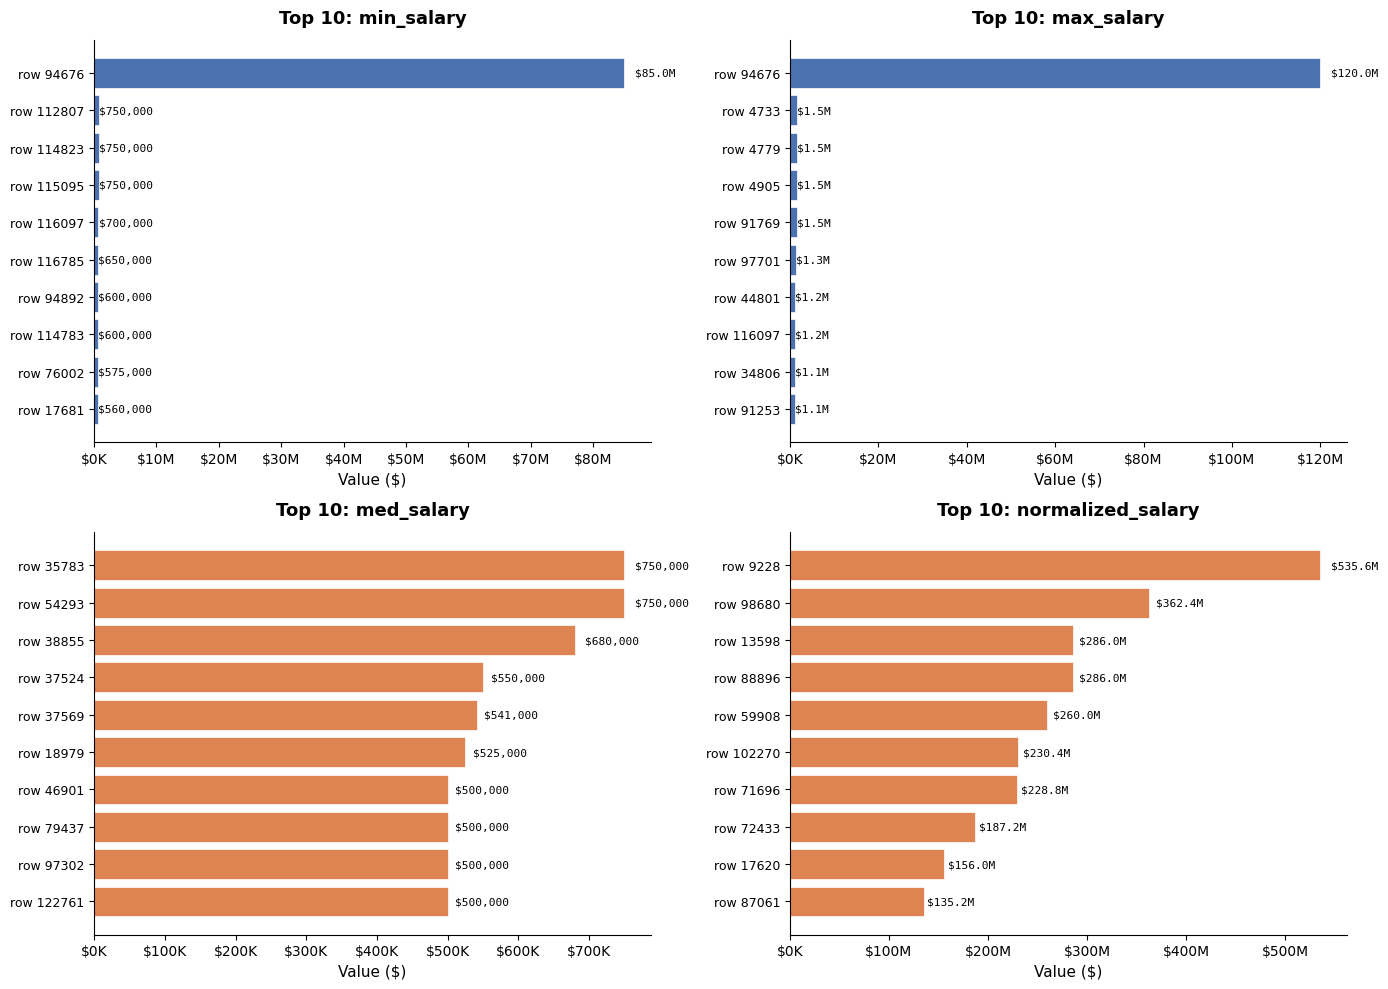


Row indices appearing in multiple top-10 lists:
  min_salary & max_salary: rows [94676, 116097]


In [55]:
import matplotlib.ticker as mticker
from itertools import combinations

salary_cols = ['min_salary', 'max_salary', 'med_salary', 'normalized_salary']
colors = ['#4C72B0', '#4C72B0', '#DD8452', '#DD8452']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col, c in zip(axes.flatten(), salary_cols, colors):
    s = df[col].dropna()
    s = s[s > 0]
    top10 = s.nlargest(10)

    bars = ax.barh(range(len(top10)), top10.values, color=c, edgecolor='white', linewidth=0.5)

    for i, (idx, val) in enumerate(top10.items()):
        label = f'${val/1e6:,.1f}M' if val >= 1e6 else f'${val:,.0f}'
        ax.text(val * 1.02, i, label, va='center', fontsize=8, fontfamily='monospace')

    ax.set_yticks(range(len(top10)))
    ax.set_yticklabels([f'row {idx}' for idx in top10.index], fontsize=9)
    ax.invert_yaxis()
    ax.set_title(f'Top 10: {col}', fontsize=13, fontweight='bold', pad=12)
    ax.set_xlabel('Value ($)', fontsize=11)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f'${x/1e6:.0f}M' if x >= 1e6 else f'${x/1e3:.0f}K'))
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

all_top10_indices = {}
for col in salary_cols:
    s = df[col].dropna()
    s = s[s > 0]
    all_top10_indices[col] = set(s.nlargest(10).index)

print("\nRow indices appearing in multiple top-10 lists:")
for col_a, col_b in combinations(salary_cols, 2):
    shared = all_top10_indices[col_a] & all_top10_indices[col_b]
    if shared:
        print(f"  {col_a} & {col_b}: rows {sorted(shared)}")

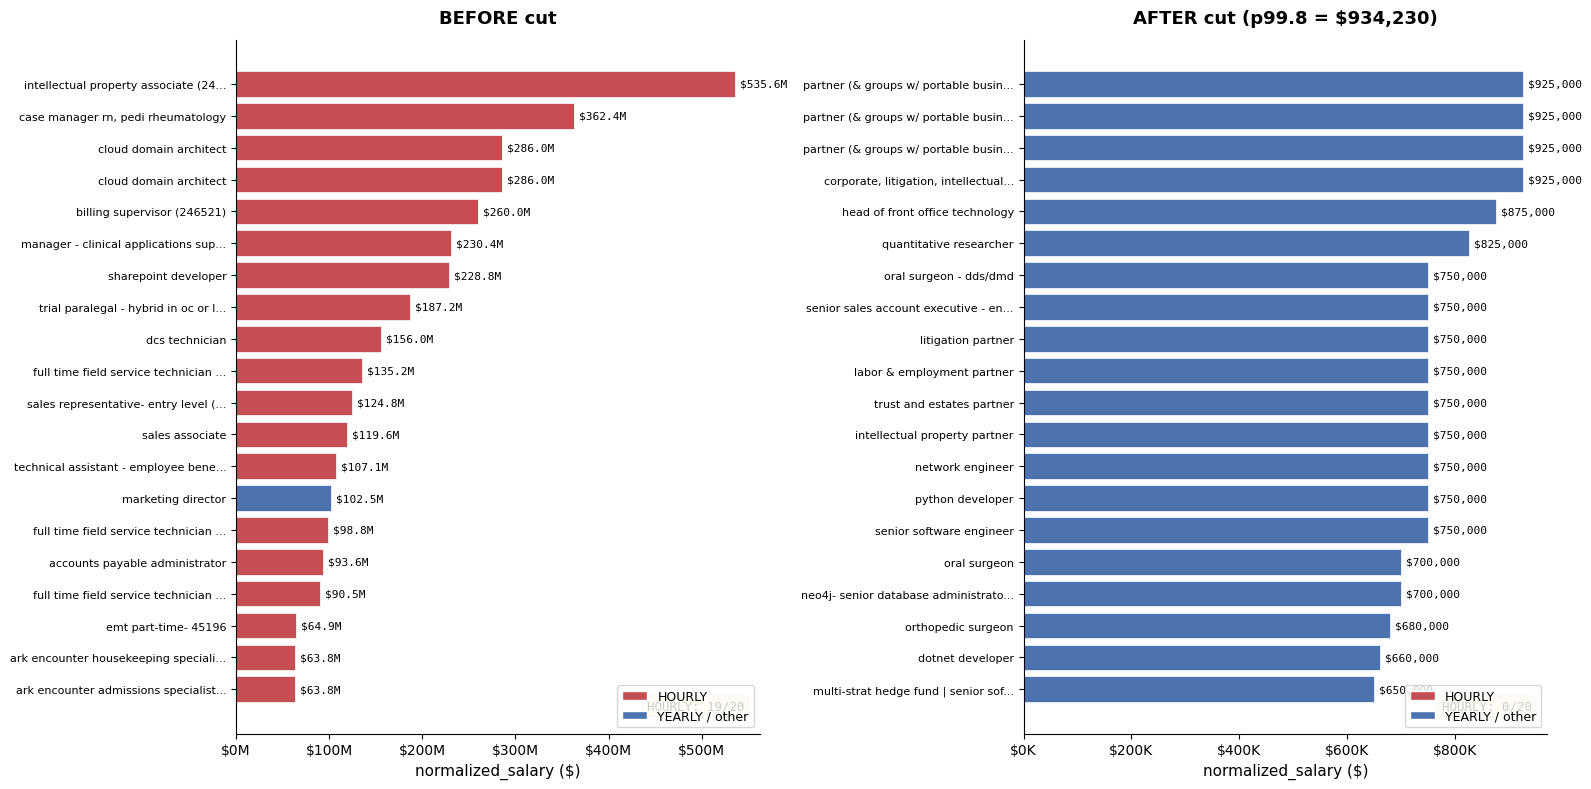

p99.89 threshold: $934,230

BEFORE - top 20 HOURLY count: 19/20
AFTER  - top 20 HOURLY count: 0/20


In [56]:
from matplotlib.patches import Patch

salary = df['normalized_salary'].dropna()
salary = salary[salary > 0]
threshold = salary.quantile(0.9989)

top20_before = df.nlargest(20, 'normalized_salary')[['normalized_salary', 'pay_period', 'title']].copy()
top20_after  = df[df['normalized_salary'] <= threshold].nlargest(20, 'normalized_salary')[['normalized_salary', 'pay_period', 'title']].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for ax, data, label in zip(axes, [top20_before, top20_after], ['BEFORE cut', f'AFTER cut (p99.8 = ${threshold:,.0f})']):
    colors = ['#C44E52' if p == 'HOURLY' else '#4C72B0' for p in data['pay_period']]
    y_pos = range(len(data))
    short_titles = [t[:35] + '...' if len(str(t)) > 35 else str(t) for t in data['title']]

    bars = ax.barh(y_pos, data['normalized_salary'].values, color=colors, edgecolor='white', linewidth=0.5)

    for i, val in enumerate(data['normalized_salary'].values):
        if val >= 1e6:
            lbl = f'${val/1e6:,.1f}M'
        else:
            lbl = f'${val:,.0f}'
        ax.text(val + data['normalized_salary'].max() * 0.01, i, lbl,
                va='center', fontsize=8, fontfamily='monospace')

    ax.set_yticks(y_pos)
    ax.set_yticklabels(short_titles, fontsize=8)
    ax.invert_yaxis()
    ax.set_title(label, fontsize=13, fontweight='bold', pad=12)
    ax.set_xlabel('normalized_salary ($)', fontsize=11)
    ax.spines[['top', 'right']].set_visible(False)

    max_val = data['normalized_salary'].max()
    if max_val >= 1e6:
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M'))
    else:
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))

    legend_handles = [Patch(facecolor='#C44E52', edgecolor='white', label='HOURLY'),
                      Patch(facecolor='#4C72B0', edgecolor='white', label='YEARLY / other')]
    ax.legend(handles=legend_handles, fontsize=9, loc='lower right')

    n_hourly = sum(1 for p in data['pay_period'] if p == 'HOURLY')
    ax.text(0.97, 0.03, f'HOURLY: {n_hourly}/{len(data)}',
            transform=ax.transAxes, ha='right', va='bottom', fontsize=9, fontfamily='monospace',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFF3CD', edgecolor='#DDDDDD', alpha=0.9))

plt.tight_layout()
plt.show()

print(f"p99.89 threshold: ${threshold:,.0f}")
print(f"\nBEFORE - top 20 HOURLY count: {sum(1 for p in top20_before['pay_period'] if p == 'HOURLY')}/20")
print(f"AFTER  - top 20 HOURLY count: {sum(1 for p in top20_after['pay_period'] if p == 'HOURLY')}/20")

### 7.2 Nullify outliers above p99.89

Values above the threshold are set to `NaN` rather than dropping the row - the text columns (title, description) are still valid and can be used for feature extraction later.

In [57]:
salary = df['normalized_salary'].dropna()
salary = salary[salary > 0]
threshold = salary.quantile(0.9989)

outlier_mask = df['normalized_salary'] > threshold
n_outliers = outlier_mask.sum()

salary_cols_to_null = ['min_salary', 'max_salary', 'med_salary', 'normalized_salary']
df.loc[outlier_mask, salary_cols_to_null] = np.nan

print(f"p99.89 threshold:      ${threshold:,.0f}")
print(f"Rows nullified:       {n_outliers} ({n_outliers / df['normalized_salary'].notna().sum() * 100:.2f}% of non-null)")
print(f"Range after treatment: ${df['normalized_salary'].min():,.0f} -- ${df['normalized_salary'].max():,.0f}")

p99.89 threshold:      $934,230
Rows nullified:       40 (0.11% of non-null)
Range after treatment: $0 -- $925,000


# 8. Final overview and dataset export

At this stage, the dataset has been cleaned and standardized through preprocessing operations such as:
- duplicate removal
- salary normalization
- text cleaning and formatting
- inconsistent value handling
- outlier treatment

Missing values are intentionally preserved at this stage because they will be handled during the feature engineering phase, where more context-aware imputation and transformation strategies will be applied.

The following overview provides a final summary of the cleaned dataset before feature engineering and exports the dataset for further processing.

In [58]:
print("=" * 60)
print("FINAL DATASET OVERVIEW")
print("=" * 60)

print(f"\nDataset shape: {df.shape}")

print(f"\nDuplicate rows remaining: {df.duplicated().sum()}")

if "normalized_salary" in df.columns:
    salary = df["normalized_salary"].dropna()

    print("\nNormalized salary statistics:")
    print(f"Minimum salary: ${salary.min():,.0f}")
    print(f"Maximum salary: ${salary.max():,.0f}")
    print(f"Average salary: ${salary.mean():,.0f}")
    print(f"Median salary: ${salary.median():,.0f}")

print("\nCategorical feature summary:")
categorical_cols = df.select_dtypes(include=["object","string"]).columns

for col in categorical_cols:
    print(f"{col}: {df[col].nunique()} unique values")

memory_usage = df.memory_usage(deep=True).sum() / 1024**2
print(f"\nMemory usage: {memory_usage:.2f} MB")

FINAL DATASET OVERVIEW

Dataset shape: (123545, 23)

Duplicate rows remaining: 3

Normalized salary statistics:
Minimum salary: $0
Maximum salary: $925,000
Average salary: $95,443
Median salary: $81,328

Categorical feature summary:
company_name: 24413 unique values
title: 71580 unique values
description: 107739 unique values
pay_period: 5 unique values
location: 8526 unique values
formatted_work_type: 7 unique values
application_type: 4 unique values
formatted_experience_level: 6 unique values
posting_domain: 4443 unique values
currency: 6 unique values

Memory usage: 878.48 MB


In [59]:
output_path = "../data/processed/cleaned_job_postings.csv"

df.to_csv(output_path, index=False)

print("\n" + "=" * 60)
print("CLEANED DATASET SAVED")
print("=" * 60)
print(f"File name: {output_path}")
print(f"Rows exported: {df.shape[0]}")
print(f"Columns exported: {df.shape[1]}")


CLEANED DATASET SAVED
File name: ../data/processed/cleaned_job_postings.csv
Rows exported: 123545
Columns exported: 23
